In [5]:
# ── Standard Libraries ─────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.metrics import precision_score, recall_score
import seaborn as sns
from skimage.metrics import structural_similarity as ssim

# ── PyTorch ────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ── PyTorch Geometric (for GNN tasks) ─────────────────────
import torch_geometric
from torch_geometric.data import Data, DataLoader as GeoDataLoader
from torch_geometric.nn import GCNConv, EdgeConv, global_mean_pool, global_max_pool

# ── Data ───────────────────────────────────────────────────
import h5py
from scipy.stats import wasserstein_distance

# ── Display ────────────────────────────────────────────────
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# ── Device ─────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"PyG version: {torch_geometric.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128
PyG version: 2.7.0


In [20]:
with h5py.File('quark_gluon_data.h5', 'r') as f:
    print("Keys:", list(f.keys()))
    for key in f.keys():
        print(f"{key}: shape = {f[key].shape}, dtype = {f[key].dtype}")

Keys: ['X_jets', 'm0', 'pt', 'y']
X_jets: shape = (139306, 125, 125, 3), dtype = float32
m0: shape = (139306,), dtype = float32
pt: shape = (139306,), dtype = float32
y: shape = (139306,), dtype = float32


In [21]:
# ── Dataset Class ──────────────────────────────────────────
class QuarkGluonDataset(Dataset):
    def __init__(self, filepath, max_samples=50000):
        with h5py.File(filepath, 'r') as f:
            self.X = torch.tensor(f['X_jets'][:max_samples], dtype=torch.float32)
            self.y = torch.tensor(f['y'][:max_samples], dtype=torch.long)

        # Normalize each channel to [0, 1]
        for c in range(3):
            ch = self.X[:, :, :, c]
            ch_max = ch.max()
            if ch_max > 0:
                self.X[:, :, :, c] = ch / ch_max

        # Reshape to (N, C, H, W) for PyTorch
        self.X = self.X.permute(0, 3, 1, 2)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

print("Dataset class defined ✅")

Dataset class defined ✅


In [6]:
# ── Basic Stats ────────────────────────────────────────────
with h5py.File('/content/ml4sci-falcon/quark_gluon_data.h5', 'r') as f:
    X = f['X_jets'][:5000]
    y = f['y'][:5000]

print(f"Dataset shape  : {X.shape}")
print(f"Label distribution:")
print(f"  Gluon (0)  : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"  Quark (1)  : {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")
print(f"\nChannel stats:")
channel_names = ['ECAL', 'HCAL', 'Tracks']
for i, name in enumerate(channel_names):
    ch = X[:, :, :, i]
    print(f"  {name} — min: {ch.min():.4f}, max: {ch.max():.4f}, mean: {ch.mean():.4f}, sparsity: {(ch==0).mean()*100:.1f}%")

Dataset shape  : (5000, 125, 125, 3)
Label distribution:
  Gluon (0)  : 2491 (49.8%)
  Quark (1)  : 2509 (50.2%)

Channel stats:
  ECAL — min: 0.0000, max: 9.8686, mean: 0.0001, sparsity: 99.5%
  HCAL — min: 0.0000, max: 1.6508, mean: 0.0000, sparsity: 98.5%
  Tracks — min: 0.0000, max: 0.1573, mean: 0.0000, sparsity: 97.3%


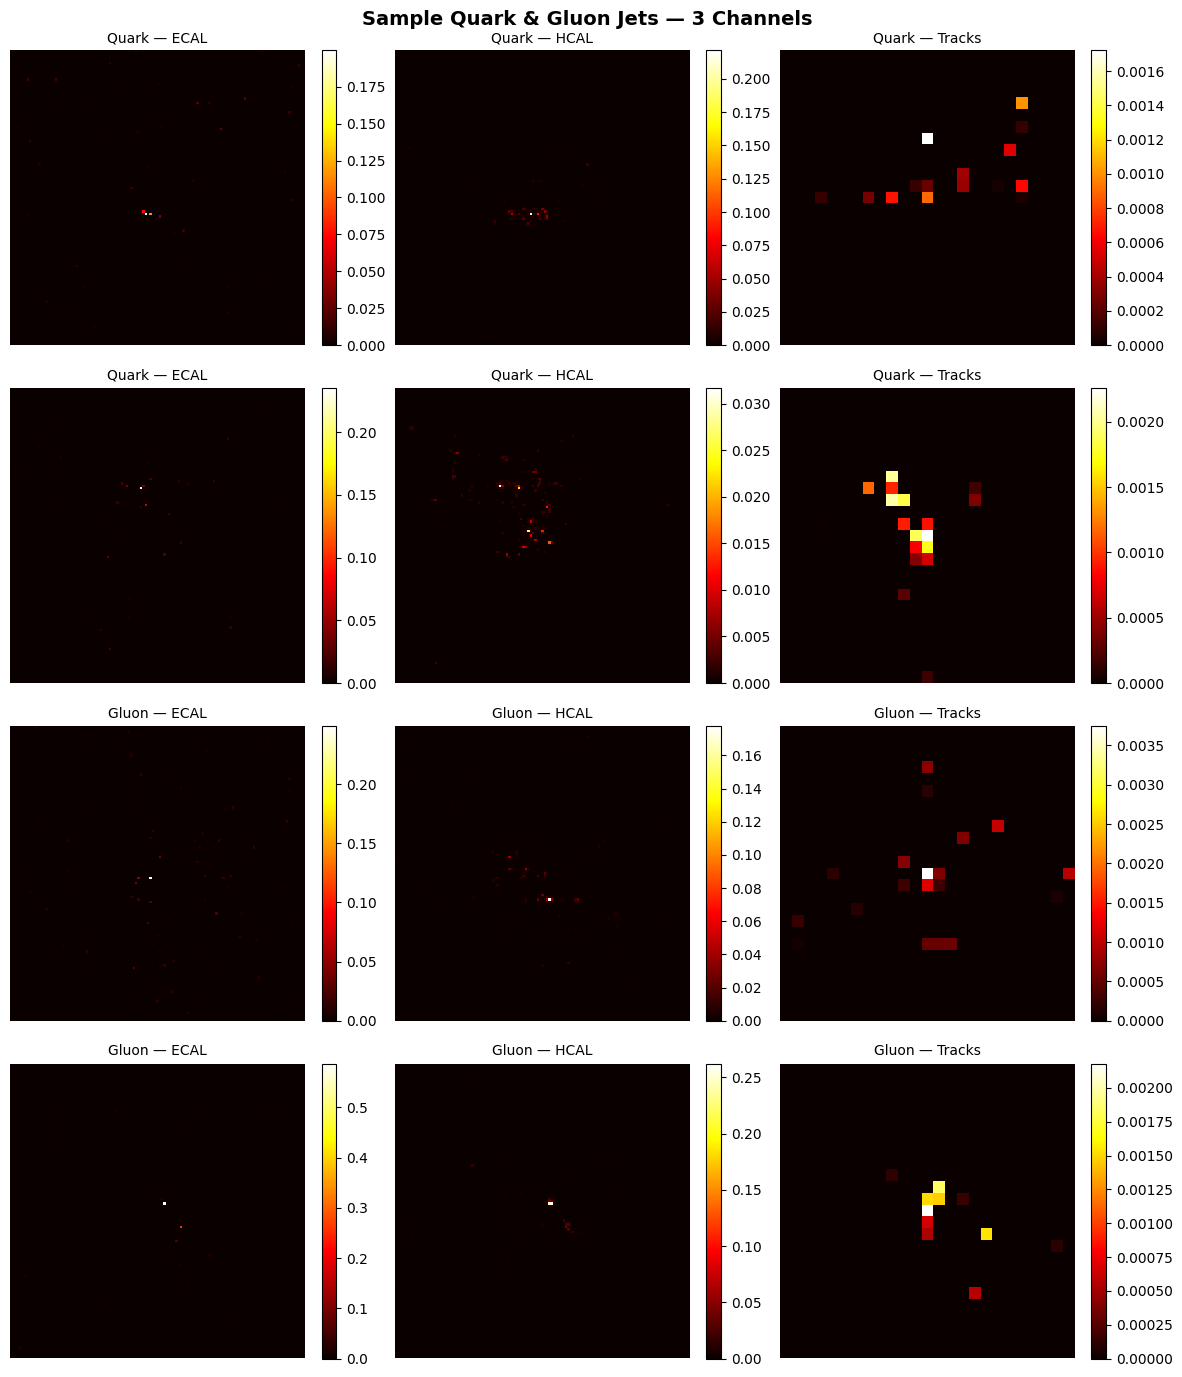

Saved ✅


In [8]:
# ── Visualize Sample Jets ──────────────────────────────────
import os

channel_names = ['ECAL', 'HCAL', 'Tracks']
fig, axes = plt.subplots(4, 3, figsize=(12, 14))
fig.suptitle('Sample Quark & Gluon Jets — 3 Channels', fontsize=14, fontweight='bold')

# 2 quark and 2 gluon samples
quark_idx = np.where(y == 1)[0][:2]
gluon_idx = np.where(y == 0)[0][:2]
samples   = [(i, 'Quark') for i in quark_idx] + [(i, 'Gluon') for i in gluon_idx]

for row, (idx, label) in enumerate(samples):
    for col, ch_name in enumerate(channel_names):
        ax = axes[row, col]
        im = ax.imshow(X[idx, :, :, col], cmap='hot', interpolation='nearest')
        ax.set_title(f'{label} — {ch_name}', fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()

# Create the 'results' directory if it doesn't exist
os.makedirs('results', exist_ok=True)

plt.savefig('results/sample_jets.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")

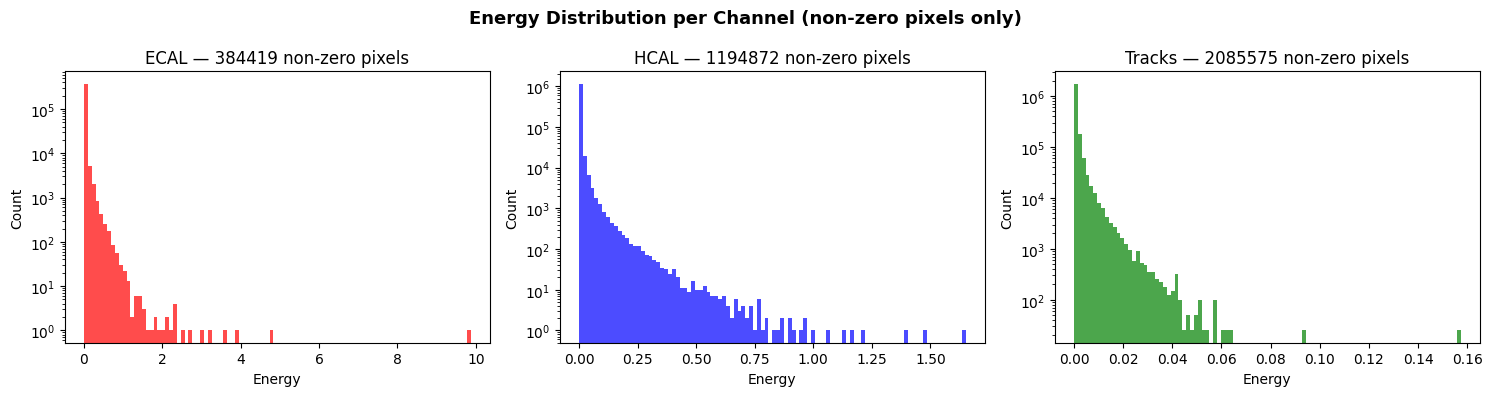

Saved ✅


In [9]:
# ── Energy Distribution per Channel ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Energy Distribution per Channel (non-zero pixels only)', fontsize=13, fontweight='bold')

channel_names = ['ECAL', 'HCAL', 'Tracks']
colors = ['red', 'blue', 'green']

for i, (name, color) in enumerate(zip(channel_names, colors)):
    ch = X[:, :, :, i].flatten()
    nonzero = ch[ch > 0]
    axes[i].hist(nonzero, bins=100, color=color, alpha=0.7)
    axes[i].set_title(f'{name} — {len(nonzero)} non-zero pixels')
    axes[i].set_xlabel('Energy')
    axes[i].set_ylabel('Count')
    axes[i].set_yscale('log')

plt.tight_layout()
plt.savefig('results/energy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")

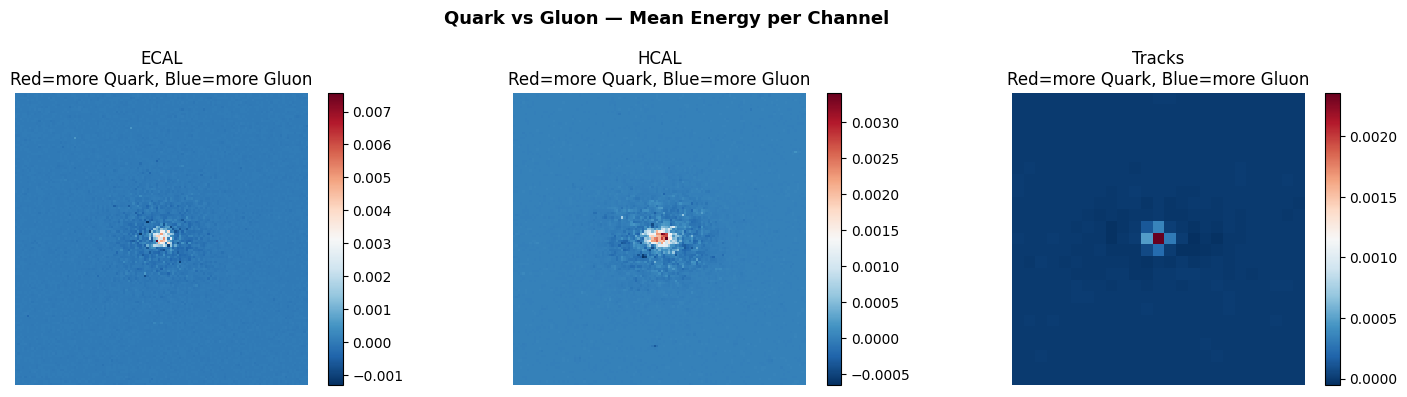

Saved ✅


In [10]:
# ── Quark vs Gluon Energy Comparison ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Quark vs Gluon — Mean Energy per Channel', fontsize=13, fontweight='bold')

quark_idx = np.where(y == 1)[0]
gluon_idx = np.where(y == 0)[0]
channel_names = ['ECAL', 'HCAL', 'Tracks']
colors_q = 'red'
colors_g = 'blue'

for i, name in enumerate(channel_names):
    q_mean = X[quark_idx, :, :, i].mean(axis=0)
    g_mean = X[gluon_idx, :, :, i].mean(axis=0)

    # Plot difference
    diff = q_mean - g_mean
    im = axes[i].imshow(diff, cmap='RdBu_r', interpolation='nearest')
    axes[i].set_title(f'{name}\nRed=more Quark, Blue=more Gluon')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.tight_layout()
plt.savefig('results/quark_vs_gluon.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")

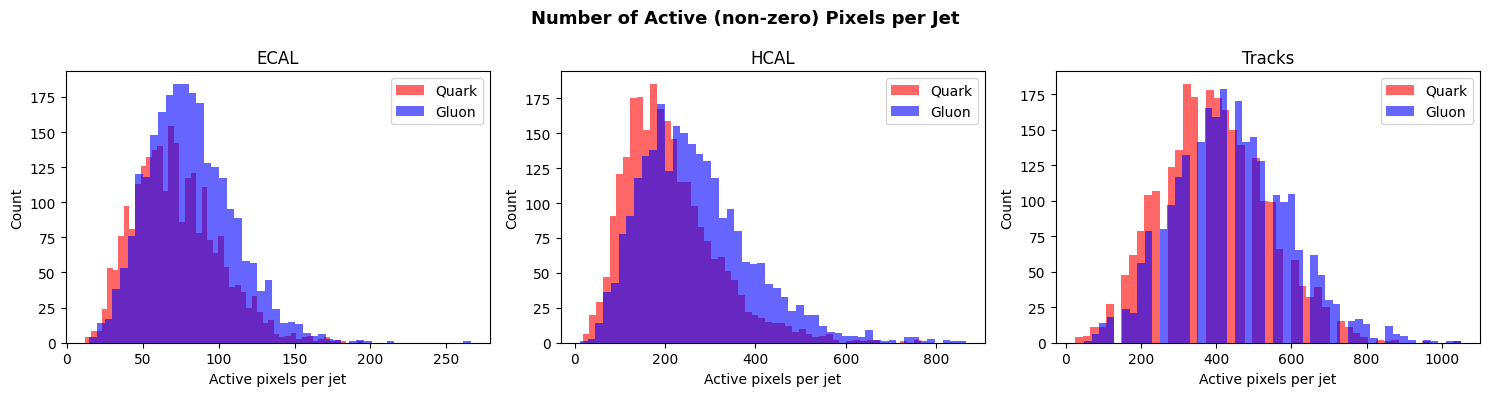

Saved ✅


In [11]:
# ── Sparsity per Jet ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Number of Active (non-zero) Pixels per Jet', fontsize=13, fontweight='bold')

channel_names = ['ECAL', 'HCAL', 'Tracks']
colors = ['red', 'blue', 'green']

for i, (name, color) in enumerate(zip(channel_names, colors)):
    active_pixels = (X[:, :, :, i] > 0).sum(axis=(1, 2))
    q_active = active_pixels[y == 1]
    g_active = active_pixels[y == 0]

    axes[i].hist(q_active, bins=50, alpha=0.6, color='red',  label='Quark')
    axes[i].hist(g_active, bins=50, alpha=0.6, color='blue', label='Gluon')
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Active pixels per jet')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.tight_layout()
plt.savefig('results/sparsity_per_jet.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")